In [1]:
import os
os.chdir(os.path.join(os.path.dirname("__file__"), ".."))
import sys
sys.path.insert(0, "..")
import matplotlib.pyplot as plt
from collections import Counter
from src.data.loaders import load_iam, load_funsd
from src.data.synthetic import generate_dataset

In [2]:
# Use small subsets for exploration only
iam_train, iam_val = load_iam(max_train=200, max_val=50)
funsd_train, funsd_test = load_funsd()
synthetic_docs = generate_dataset(n=50, seed=42)
print(f"IAM train: {len(iam_train)}, val: {len(iam_val)}")
print(f"FUNSD train: {len(funsd_train)}, test: {len(funsd_test)}")
print(f"Synthetic: {len(synthetic_docs)}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Teklia/IAM-line' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nielsr/funsd' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


IAM train: 200, val: 50
FUNSD train: 149, test: 50
Synthetic: 50


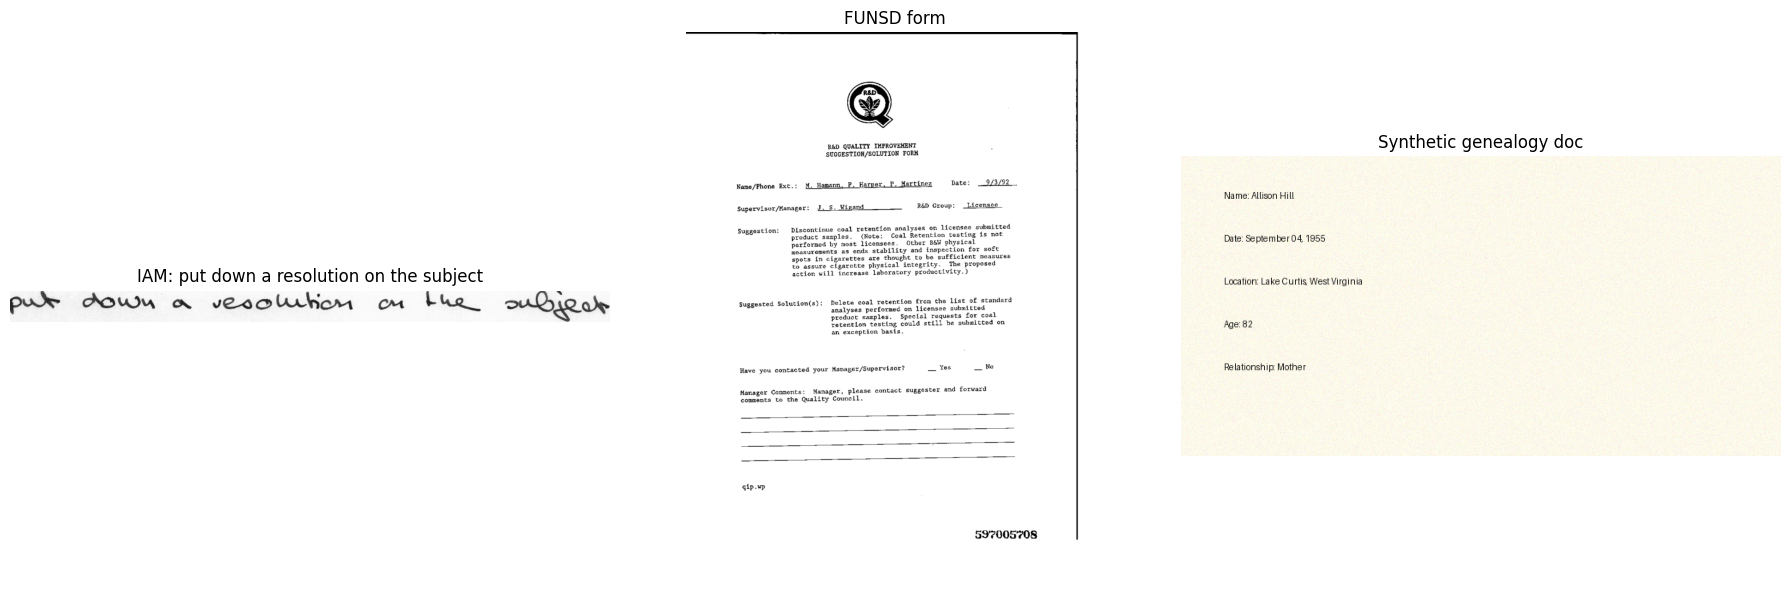

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(iam_train[0].image)
axes[0].set_title(f"IAM: {iam_train[0].text[:40]}")
axes[1].imshow(funsd_train[0].image)
axes[1].set_title("FUNSD form")
axes[2].imshow(synthetic_docs[0].image)
axes[2].set_title("Synthetic genealogy doc")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

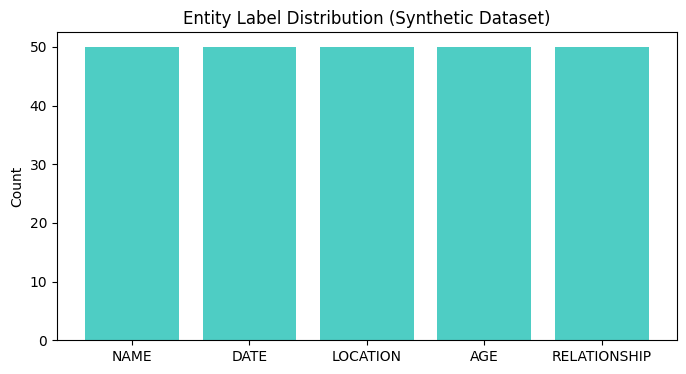

Counter({'NAME': 50, 'DATE': 50, 'LOCATION': 50, 'AGE': 50, 'RELATIONSHIP': 50})


In [4]:
all_labels = [e.label for doc in synthetic_docs for e in doc.entities]
label_counts = Counter(all_labels)
plt.figure(figsize=(8, 4))
plt.bar(label_counts.keys(), label_counts.values(), color="#4ECDC4")
plt.title("Entity Label Distribution (Synthetic Dataset)")
plt.ylabel("Count")
plt.show()
print(label_counts)

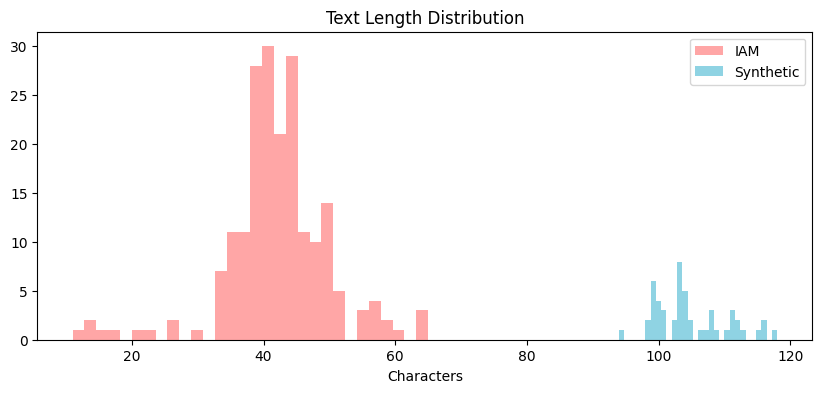

In [5]:
iam_lengths = [len(doc.text) for doc in iam_train]
synth_lengths = [len(doc.text) for doc in synthetic_docs]
plt.figure(figsize=(10, 4))
plt.hist(iam_lengths, bins=30, alpha=0.6, label="IAM", color="#FF6B6B")
plt.hist(synth_lengths, bins=30, alpha=0.6, label="Synthetic", color="#45B7D1")
plt.legend()
plt.title("Text Length Distribution")
plt.xlabel("Characters")
plt.show()